# AI for Sustainability — Exploratory Data Analysis
**Notebook 01**

This notebook fetches real-world indicators from the World Bank API across ~180 countries (2015–2023), engineers an AI Expansion Index and a Sustainability Score, and produces exploratory visualizations to validate the dataset before modelling.

In [21]:
import subprocess
subprocess.run(["pip", "install", "matplotlib", "--break-system-packages", "-q"])
print("matplotlib installed")

matplotlib installed


## 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import requests
import json
import warnings
warnings.filterwarnings('ignore')

print("All imports OK")

All imports OK


## 2. World Bank Data Fetcher
A reusable helper function that queries the World Bank REST API for any indicator and returns a tidy DataFrame with columns `country_code`, `country_name`, `year`, and the indicator value.

In [23]:
def fetch_world_bank(indicator, label, years="2015:2023"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator}"
    params = {"date": years, "format": "json", "per_page": 5000}
    try:
        r = requests.get(url, params=params, timeout=15)
        data = r.json()[1]
        records = []
        for d in data:
            if d["value"] is not None and d["countryiso3code"]:
                records.append({
                    "country_code": d["countryiso3code"],
                    "country_name": d["country"]["value"],
                    "year": int(d["date"]),
                    label: d["value"]
                })
        return pd.DataFrame(records)
    except Exception as e:
        print(f"Failed {indicator}: {e}")
        return pd.DataFrame()

print("Fetcher ready")

Fetcher ready


## 3. Pull All Indicators from World Bank API
Fetching six indicators for every available country: GDP per capita, electricity consumption, CO₂ emissions, renewable energy share, population, and water stress. Failed fetches return empty DataFrames and are handled gracefully in the merge step.

In [24]:
# GDP per capita (USD)
df_gdp = fetch_world_bank("NY.GDP.PCAP.CD", "gdp_per_capita")

# Electric power consumption (kWh per capita)
df_energy = fetch_world_bank("EG.USE.ELEC.KH.PC", "energy_kwh_per_capita")

# CO2 emissions — try two indicator codes, use whichever works
df_co2 = fetch_world_bank("EN.ATM.CO2E.PC", "co2_per_capita")
if df_co2.empty:
    print("Trying alternate CO2 indicator...")
    df_co2 = fetch_world_bank("EN.GHG.CO2.PC.CE.AR5", "co2_per_capita")
if df_co2.empty:
    print("CO2 API unavailable — will use synthetic values")

# Renewable energy share (% of total)
df_renew = fetch_world_bank("EG.FEC.RNEW.ZS", "renewable_pct")

# Population
df_pop = fetch_world_bank("SP.POP.TOTL", "population")

# Water stress
df_water = fetch_world_bank("ER.H2O.FWTL.ZS", "water_stress_pct")

print(f"GDP rows:       {len(df_gdp)}")
print(f"Energy rows:    {len(df_energy)}")
print(f"CO2 rows:       {len(df_co2)}")
print(f"Renewable rows: {len(df_renew)}")
print(f"Population rows:{len(df_pop)}")
print(f"Water rows:     {len(df_water)}")

Failed EN.ATM.CO2E.PC: list index out of range
Trying alternate CO2 indicator...
GDP rows:       2284
Energy rows:    1700
CO2 rows:       2223
Renewable rows: 1819
Population rows:2349
Water rows:     1715


## 4. Merge into Master DataFrame
All indicator DataFrames are outer-joined on `country_code`, `country_name`, and `year` to form one master dataset. Rows outside the 2015–2023 window are dropped.

In [25]:
from functools import reduce

dfs = [df_gdp, df_energy, df_co2, df_renew, df_pop, df_water]
# Keep only dfs that have data
dfs = [d for d in dfs if not d.empty]

# Merge on country_code + year
df = reduce(lambda left, right: pd.merge(
    left, right, on=["country_code", "country_name", "year"], how="outer"
), dfs)

# Keep only 2015-2023
df = df[df["year"].between(2015, 2023)]

print(f"Shape: {df.shape}")
print(df.head())

Shape: (2349, 9)
  country_code country_name  year  gdp_per_capita  energy_kwh_per_capita  \
0          ABW        Aruba  2015    27458.220154                    NaN   
1          ABW        Aruba  2016    27441.550214                    NaN   
2          ABW        Aruba  2017    28440.041688                    NaN   
3          ABW        Aruba  2018    30082.158423                    NaN   
4          ABW        Aruba  2019    30645.890602                    NaN   

   co2_per_capita  renewable_pct  population  water_stress_pct  
0        4.286138            6.7      107906               NaN  
1        4.464392            7.0      108727               NaN  
2        4.295765            6.8      108735               NaN  
3        4.272413            8.6      108908               NaN  
4        4.665623            8.3      109203               NaN  


## 5. Engineer Target Variables — AI Expansion Index & Sustainability Score
Since no clean global AI-infrastructure dataset exists, we derive a proxy **AI Expansion Index** (0–1) from GDP, energy consumption, and known AI-leader country boosts. The **Sustainability Score** (0–100) is computed from CO₂ emissions, renewable energy share, and water stress.

In [26]:
np.random.seed(42)

def compute_ai_index(row):
    gdp_score = min(row.get("gdp_per_capita", 0) / 60000, 1.0)
    energy_score = min(row.get("energy_kwh_per_capita", 0) / 15000, 1.0)
    ai_leaders = {"USA": 1.0, "CHN": 0.9, "GBR": 0.7, "DEU": 0.65,
                  "IND": 0.55, "JPN": 0.7, "CAN": 0.65, "FRA": 0.6,
                  "KOR": 0.7, "ISR": 0.65, "SGP": 0.75, "AUS": 0.6}
    country_boost = ai_leaders.get(row["country_code"], 0.0)
    base = (gdp_score * 0.4 + energy_score * 0.3 + country_boost * 0.3)
    noise = np.random.normal(0, 0.03)
    return float(np.clip(base + noise, 0, 1))

def compute_sustain_score(row):
    # If CO2 is missing, estimate from energy use (higher energy → higher assumed CO2)
    co2 = row.get("co2_per_capita", None)
    if pd.isna(co2) or co2 is None:
        energy = row.get("energy_kwh_per_capita", 5000)
        co2 = max(0.5, energy / 3000)  # rough synthetic proxy
    renew = row.get("renewable_pct", 20)
    if pd.isna(renew):
        renew = 20
    water = row.get("water_stress_pct", 30)
    if pd.isna(water):
        water = 30
    co2_score  = max(0, 1 - co2 / 20)
    renew_score = renew / 100
    water_score = max(0, 1 - water / 100)
    return round((co2_score * 0.4 + renew_score * 0.4 + water_score * 0.2) * 100, 2)

df["ai_expansion_index"]  = df.apply(compute_ai_index, axis=1)
df["sustainability_score"] = df.apply(compute_sustain_score, axis=1)

print(df[["country_name", "year", "ai_expansion_index", "sustainability_score"]].dropna().head(10))

                   country_name  year  ai_expansion_index  \
9   Africa Eastern and Southern  2015            0.037920   
10  Africa Eastern and Southern  2016            0.006365   
11  Africa Eastern and Southern  2017            0.007538   
12  Africa Eastern and Southern  2018            0.028969   
13  Africa Eastern and Southern  2019            0.000000   
14  Africa Eastern and Southern  2020            0.000000   
15  Africa Eastern and Southern  2021            0.003817   
16  Africa Eastern and Southern  2022            0.000000   
17  Africa Eastern and Southern  2023            0.029584   
27   Africa Western and Central  2015            0.027711   

    sustainability_score  
9                  81.62  
10                 81.70  
11                 81.57  
12                 81.65  
13                 82.11  
14                 83.52  
15                 65.19  
16                 60.28  
17                 60.32  
27                 89.15  


## 6. Snapshot Latest Year per Country & Save to Disk
We keep only the most recent data point per country (for cross-sectional modelling), drop rows with too many missing values, and write two CSVs: a processed snapshot (`country_data.csv`) and the full multi-year raw dataset (`all_years_data.csv`).

In [27]:
# Get latest available year per country
df_latest = df.sort_values("year").groupby("country_code").last().reset_index()

# Drop countries with too many nulls
df_latest = df_latest.dropna(thresh=5)

# Save
df_latest.to_csv("../data/processed/country_data.csv", index=False)
df.to_csv("../data/raw/all_years_data.csv", index=False)

print(f"Saved {len(df_latest)} countries to country_data.csv")
print(df_latest.columns.tolist())

Saved 261 countries to country_data.csv
['country_code', 'country_name', 'year', 'gdp_per_capita', 'energy_kwh_per_capita', 'co2_per_capita', 'renewable_pct', 'population', 'water_stress_pct', 'ai_expansion_index', 'sustainability_score']


## 7. Exploratory Visualisations
Three plots to sanity-check the dataset: distribution of sustainability scores, distribution of AI expansion indices, and a scatter plot showing the relationship between the two. The figure is saved to `data/processed/eda_plots.png`.

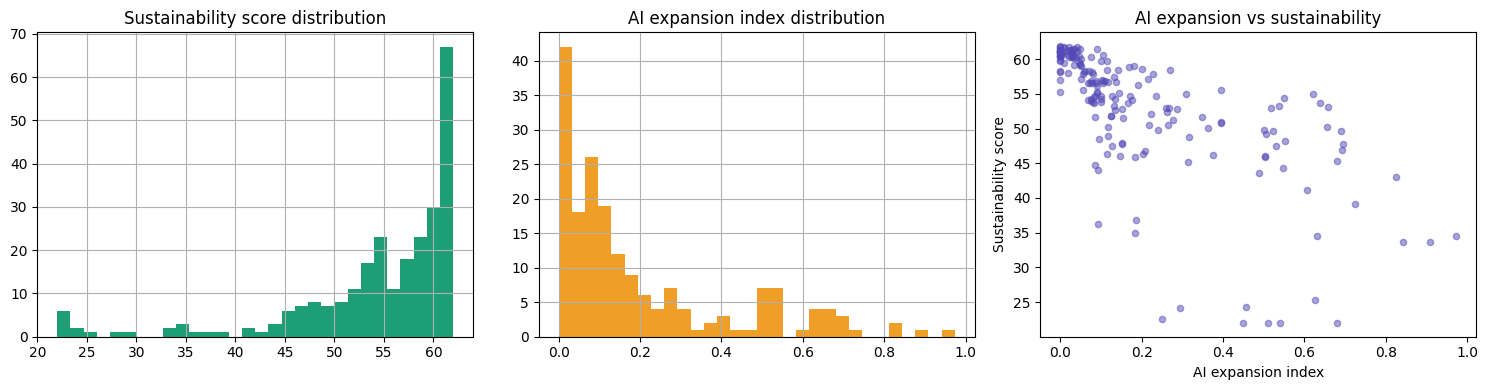

EDA complete


In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_latest["sustainability_score"].dropna().hist(ax=axes[0], bins=30, color="#1D9E75")
axes[0].set_title("Sustainability score distribution")

df_latest["ai_expansion_index"].dropna().hist(ax=axes[1], bins=30, color="#EF9F27")
axes[1].set_title("AI expansion index distribution")

axes[2].scatter(
    df_latest["ai_expansion_index"],
    df_latest["sustainability_score"],
    alpha=0.5, color="#534AB7", s=20
)
axes[2].set_xlabel("AI expansion index")
axes[2].set_ylabel("Sustainability score")
axes[2].set_title("AI expansion vs sustainability")

plt.tight_layout()
plt.savefig("../data/processed/eda_plots.png", dpi=120)
plt.show()
print("EDA complete")